In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

INPUT_CHANGE_CSV = "../results/diff_pix/input_change_stats.csv"
RESULTS_CSV = "../results/diff_pix/results.csv"

df_change = pd.read_csv(INPUT_CHANGE_CSV)
df_res = pd.read_csv(RESULTS_CSV)

df_change.head(), df_res.head()

(             image                     tag  is_global  segment_index     eps  \
 0  n01558993_robin  n01558993_robin_global       True             -1  0.0001   
 1  n01558993_robin  n01558993_robin_global       True             -1  0.0001   
 2  n01558993_robin  n01558993_robin_global       True             -1  0.0001   
 3  n01558993_robin  n01558993_robin_global       True             -1  0.0001   
 4  n01558993_robin  n01558993_robin_global       True             -1  0.0001   
 
     k  score  bbox  num_changed  num_fixed   total  percent_changed pattern  
 0  15    NaN   NaN           45     150483  150528         0.029895  global  
 1  30    NaN   NaN           90     150438  150528         0.059790  global  
 2  45    NaN   NaN          135     150393  150528         0.089684  global  
 3  60    NaN   NaN          180     150348  150528         0.119579  global  
 4  75    NaN   NaN          225     150303  150528         0.149474  global  ,
    instance_id               onnx  \

In [12]:
# sort by instance_id (ascending)
df_sorted = df_res.sort_values(by="instance_id")

# (optional) reset index after sorting
df_sorted = df_sorted.reset_index(drop=True)

df_sorted

,instance_id,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable,k,eps
0,1,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k15_eps_0.0001.v...,1200,timeout False,-2.712000e+11,30.0,1270.399932,1288.957838,0,15.0,0.0001
1,2,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k30_eps_0.0001.v...,1200,timeout False,-1.922129e+11,15.0,1369.270332,1389.730186,0,30.0,0.0001
2,31,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k60211_eps_0.000...,1200,sat True,NaN,NaN,NaN,56.849453,0,60211.0,0.0001
3,32,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k75264_eps_0.000...,1200,sat True,NaN,NaN,NaN,56.781669,0,75264.0,0.0001
4,33,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k90317_eps_0.000...,1200,sat True,NaN,NaN,NaN,56.690137,0,90317.0,0.0001
...,...,...,...,...,...,...,...,...,...,...,...,...
97,249,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k90317_eps_0.010...,1200,sat True,NaN,NaN,NaN,1881.956834,0,90317.0,0.0100
98,250,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k105370_eps_0.01...,1200,sat True,NaN,NaN,NaN,1897.026767,0,105370.0,0.0100
99,251,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k120422_eps_0.01...,1200,sat True,NaN,NaN,NaN,1894.667643,0,120422.0,0.0100
100,252,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k135475_eps_0.01...,1200,sat True,NaN,NaN,NaN,1892.150240,0,135475.0,0.0100


In [7]:
def parse_vnnlib(vnnlib):
    name = vnnlib.split("/")[-1].replace(".vnnlib", "")
    m = re.search(r"_k(\d+)_eps_([0-9.]+)$", name)
    if not m:
        return None, None
    return int(m.group(1)), float(m.group(2))

df_res[["k", "eps"]] = df_res["vnnlib"].apply(
    lambda x: pd.Series(parse_vnnlib(x))
)

In [8]:
merged = df_res.merge(
    df_change,
    on=["k", "eps"],
    how="inner"
)

# Ensure numeric
for c in ["percent_changed", "num_changed", "all_time", "bab_time"]:
    if c in merged.columns:
        merged[c] = pd.to_numeric(merged[c], errors="coerce")

merged = merged.dropna(subset=["percent_changed"])
merged.head()

,instance_id,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable,...,tag,is_global,segment_index,score,bbox,num_changed,num_fixed,total,percent_changed,pattern
0,168,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k9032_eps_0.0010...,1200,sat True,NaN,NaN,NaN,56.444896,0,...,n01558993_robin_global,True,-1,NaN,NaN,27096,123432,150528,18.000638,global
1,35,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k120422_eps_0.00...,1200,sat True,NaN,NaN,NaN,56.801735,0,...,n01558993_robin_global,True,-1,NaN,NaN,150528,0,150528,100.000000,global
2,169,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k10537_eps_0.001...,1200,sat True,NaN,NaN,NaN,56.764388,0,...,n01558993_robin_global,True,-1,NaN,NaN,31611,118917,150528,21.000080,global
3,65,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k30106_eps_0.000...,1200,sat True,NaN,NaN,NaN,56.862707,0,...,n01558993_robin_global,True,-1,NaN,NaN,90318,60210,150528,60.000797,global
4,167,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k7526_eps_0.0010...,1200,sat True,NaN,NaN,NaN,56.802748,0,...,n01558993_robin_global,True,-1,NaN,NaN,22578,127950,150528,14.999203,global


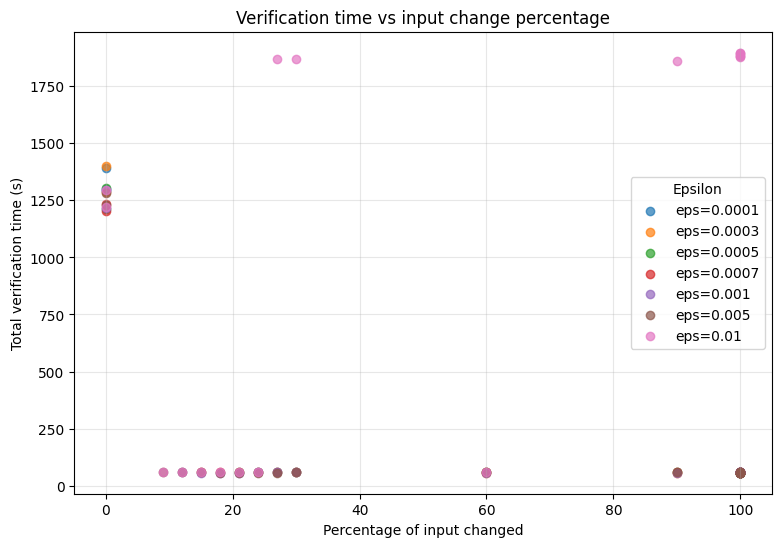

In [9]:
plt.figure(figsize=(9,6))

for eps, g in merged.groupby("eps"):
    plt.scatter(
        g["percent_changed"],
        g["all_time"],
        alpha=0.7,
        label=f"eps={eps}"
    )

plt.xlabel("Percentage of input changed")
plt.ylabel("Total verification time (s)")
plt.title("Verification time vs input change percentage")
plt.legend(title="Epsilon")
plt.grid(alpha=0.3)
plt.show()

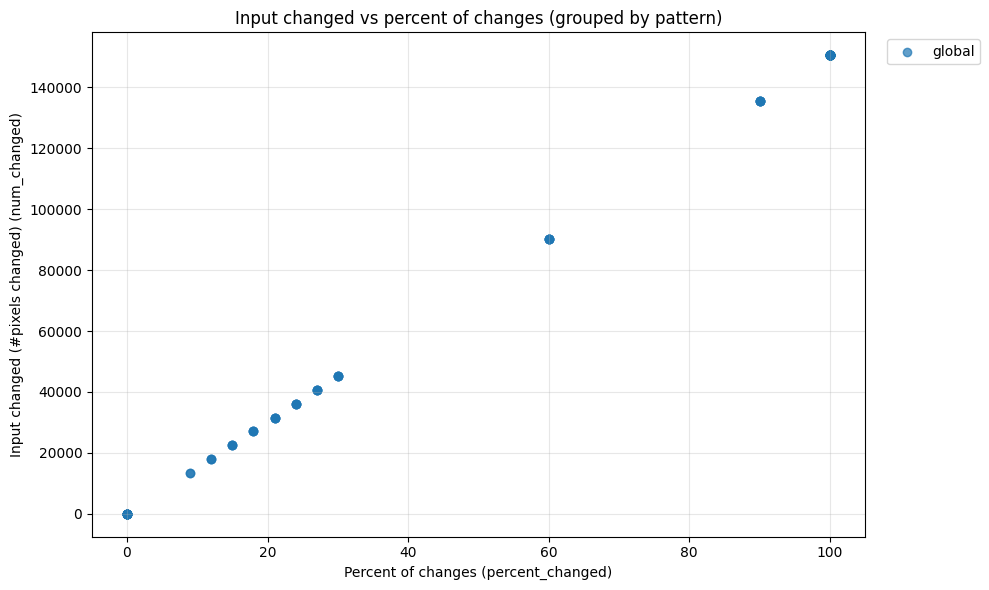

In [6]:
plt.figure(figsize=(10, 6))

for pat, g in plot_df.groupby("pattern"):
    plt.scatter(g["percent_changed"], g["num_changed"], alpha=0.7, label=pat)

plt.xlabel("Percent of changes (percent_changed)")
plt.ylabel("Input changed (#pixels changed) (num_changed)")
plt.title("Input changed vs percent of changes (grouped by pattern)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()